In [ ]:
%pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.4 MB/s eta 0:00:00


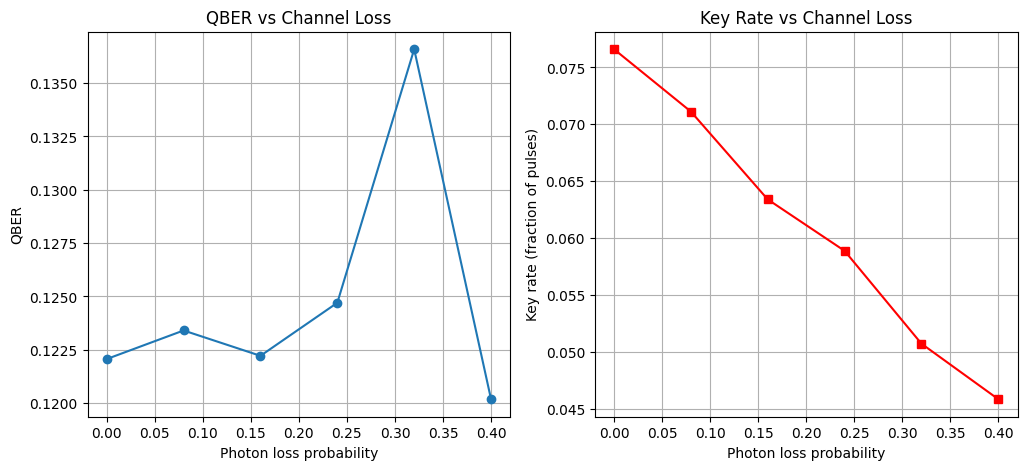


=== QKD Key Info ===
Alice sifted key:  [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0]
Bob sifted key:    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0]
Sifted key length: 32
Errors: 1, QBER: 2.5000%
Final shared key (128 bits hex): 64ea62ee5c091d857947694d3ce937d8

=== Message Transmission ===
Original message: HELLO BOB
Cipher text: ,¯.¢)_Ê;
Decrypted message: HELLO BOB


In [ ]:
import random, hashlib
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel, depolarizing_error

# ---------- Parameters ----------
N = 500       # number of pulses per trial
trials = 50   # number of repetitions for averaging
p_signal, p_decoy, p_vacuum = 0.7, 0.25, 0.05
loss_probs = np.linspace(0.0, 0.4, 6)  # sweep photon loss [0% to 40%]
misalignment_prob = 0.05
depol_error_rate = 0.05

# New parameters (realistic imperfections)
eta_det = 0.2        # detector efficiency (20%)
p_dark = 0.01        # dark count probability (1%)

backend = Aer.get_backend('qasm_simulator')

# ---------- Utilities ----------
def privacy_amplification(bits, final_len=128):
    concat = ''.join(str(b) for b in bits)
    digest = hashlib.sha256(concat.encode()).digest()
    return digest[:final_len//8]

def str_to_bits(s):
    return [int(b) for c in s for b in format(ord(c),'08b')]

def bits_to_str(bits):
    chars = []
    for i in range(0,len(bits),8):
        byte = bits[i:i+8]
        if len(byte)<8:
            byte += [0]*(8-len(byte))
        chars.append(chr(int(''.join(map(str,byte)),2)))
    return ''.join(chars)

def run_trial(loss_prob):
    noise_model = NoiseModel()
    error = depolarizing_error(depol_error_rate, 1)
    noise_model.add_all_qubit_quantum_error(error, ['x','h','measure'])

    pulses = []
    for _ in range(N):
        # Choose decoy type
        r = random.random()
        if r < p_signal:
            decoy = 'signal'
        elif r < p_signal + p_decoy:
            decoy = 'decoy'
        else:
            decoy = 'vacuum'

        alice_bit = random.randint(0,1)
        alice_basis = random.choice(['Z','X'])
        bob_basis = random.choice(['Z','X'])

        # Photon lost or detector missed it
        if decoy == 'vacuum' or random.random() < loss_prob or random.random() > eta_det:
            # Dark count possibility
            if random.random() < p_dark:
                bob_bit = random.randint(0,1)
                pulses.append({'decoy': decoy, 'a_bit': alice_bit, 'a_basis': alice_basis,
                               'b_bit': bob_bit, 'b_basis': bob_basis, 'click': True, 'dark': True})
            else:
                pulses.append({'decoy': decoy, 'a_bit': alice_bit, 'a_basis': alice_basis,
                               'b_bit': None, 'b_basis': bob_basis, 'click': False, 'dark': False})
            continue

        # Prepare qubit
        qc = QuantumCircuit(1,1)
        if alice_bit == 1:
            qc.x(0)
        if alice_basis == 'X':
            qc.h(0)
        if bob_basis == 'X':
            qc.h(0)
        qc.measure(0,0)

        result = backend.run(qc, shots=1, noise_model=noise_model).result()
        counts = result.get_counts()
        bob_bit = int(list(counts.keys())[0])

        # Misalignment error
        if random.random() < misalignment_prob:
            bob_bit = 1 - bob_bit

        pulses.append({'decoy': decoy, 'a_bit': alice_bit, 'a_basis': alice_basis,
                       'b_bit': bob_bit, 'b_basis': bob_basis, 'click': True, 'dark': False})

    # Sifting
    matches = [p for p in pulses if p['click'] and p['a_basis']==p['b_basis']]
    alice_key = [p['a_bit'] for p in matches]
    bob_key   = [p['b_bit'] for p in matches]

    # QBER
    errors = sum(1 for a,b in zip(alice_key,bob_key) if a!=b)
    qber = errors/len(alice_key) if alice_key else 0

    # Key rate
    key_rate = max(0, len(alice_key)/N * (1 - 2*qber))

    signal_matches = [p for p in matches if p['decoy']=='signal']

    alice_key_signal = [p['a_bit'] for p in signal_matches]
    bob_key_signal  = [p['b_bit'] for p in signal_matches]


    return qber, key_rate, alice_key_signal, bob_key_signal, errors, qber, pulses

# ---------- Run sweeps ----------
avg_qbers = []
avg_key_rates = []

for loss in loss_probs:
    qbers = []
    rates = []
    for _ in range(trials):
        q, r, alice_key, bob_key, errors, qber, pulses = run_trial(loss)
        qbers.append(q)
        rates.append(r)
    avg_qbers.append(np.mean(qbers))
    avg_key_rates.append(np.mean(rates))

# ---------- Plot ----------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_probs, avg_qbers, 'o-', label="QBER")
plt.xlabel("Photon loss probability")
plt.ylabel("QBER")
plt.title("QBER vs Channel Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(loss_probs, avg_key_rates, 's-', color='red', label="Key Rate")
plt.xlabel("Photon loss probability")
plt.ylabel("Key rate (fraction of pulses)")
plt.title("Key Rate vs Channel Loss")
plt.grid(True)

plt.show()

# ---------- Print results for the last run ----------
print("\n=== QKD Key Info ===")
print("Alice sifted key: ", alice_key)
print("Bob sifted key:   ", bob_key)
print(f"Sifted key length: {len(alice_key)}")
print(f"Errors: {errors}, QBER: {qber:.4%}")

# Final shared key
final_key = privacy_amplification(alice_key, final_len=128)
print("Final shared key (128 bits hex):", final_key.hex())

# ---------- Message Transmission ----------
message = "HELLO BOB"
msg_bits = str_to_bits(message)
key_bits = [int(b) for byte in final_key for b in format(byte,'08b')]
key_bits = key_bits[:len(msg_bits)]
cipher_bits = [m ^ k for m,k in zip(msg_bits,key_bits)]
cipher_text = bits_to_str(cipher_bits)

# Bob decrypts
dec_bits = [c ^ k for c,k in zip(cipher_bits,key_bits)]
decrypted_message = bits_to_str(dec_bits)

print("\n=== Message Transmission ===")
print("Original message:", message)
print("Cipher text:", cipher_text)
print("Decrypted message:", decrypted_message)